In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import os .path

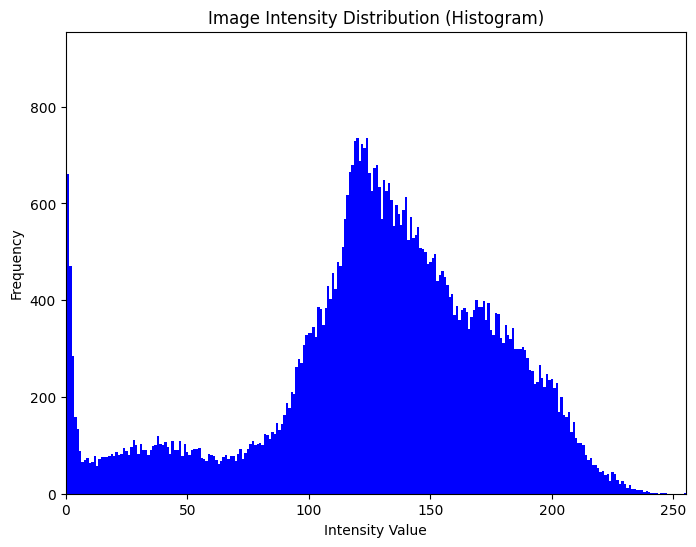

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load an image using OpenCV (replace 'image.jpg' with your image file)
image = cv2.imread('/kaggle/input/rsna-final-36-v14/Intensity_Distribution/Intensity_Distribution/Image-149.JPEG')

# Calculate the histogram of the image
hist = cv2.calcHist([image], [0], None, [256], [0, 256])

# Flatten the histogram to create a 1D array
hist = hist.flatten()

# Create an array of intensity values from 0 to 255
intensity_values = np.arange(256)

# Plot the intensity distribution (histogram)
plt.figure(figsize=(8, 6))
plt.bar(intensity_values, hist, width=1.0, color='blue')
plt.title('Image Intensity Distribution (Histogram)')
plt.xlabel('Intensity Value')
plt.ylabel('Frequency')
plt.xlim(0, 255)  # Set the x-axis limit to 0-255 (intensity values)
plt.ylim(0, 955)  # Set the x-axis limit to 0-255 (intensity values)
plt.savefig('/kaggle/working/Original-Image-Intensity.pdf', format='pdf', bbox_inches='tight')
plt.show()
plt.close()

In [4]:
#Dataset-1
os.chdir("/kaggle/input/rsna-final-36-v14/")
# path="/kaggle/input/rsna-final-36-v14/Dataset_One(36_Patients)/Dataset_One(36_Patients)";
path="/kaggle/input/rsna-final-36-v14/train4/train4";

classes=os.listdir(path)

In [5]:
x=[]
y=[]
for fol in classes:
        seq=os.listdir(path+u'/'+fol)
        for img in seq:
#           if(img=='T1wCE'):
            imgg=img
            im=os.listdir(path+u'/'+fol+u'/'+img)
            for mri in im:
                pat=path+u'/'+fol+u'/'+img+u'/'+mri
                fimg=mpimg.imread(pat);
#                 x.append(fimg)
                if fol in [
                           '00044','00045','00049','00053','00061','00064','00072','00081','00088']:
                    x.append(fimg)
                    y.append(0)
                elif fol in [
                             '00025','00026','00028','00031',  '00033','00035','00043','00046','00048']:
                    x.append(fimg)
                    y.append(1)

In [6]:
x=np.array(x)
y=np.array(y)

In [7]:
# Define the list
k=[]
j=[]
# Loop through the list and check for elements that are zero
for element in y:
    if element == 0:
        j.append(element)
    else:
        k.append(element)
print(len(k))
print(len(j))

2164
2676


In [8]:
import numpy
n=x.shape[0]
print("Total Images:",n)
randomize=numpy.arange(n)
# numpy.random.seed(36)
numpy.random.shuffle(randomize)
# print(randomize)
x=x[randomize]
print("Length of Images:",len(x))
y=y[randomize]
print("Length of Labels:",len(y))

test_split=round(n*8/10)
print("Test",test_split)

x_train=x[:test_split]
x_test=x[test_split:]
y_train=y[:test_split]
y_test=y[test_split:]


print("x_train",x_train.shape)
print("x_test",x_test.shape)
print("y_train",y_train.shape)
print("y_test",y_test.shape)

Total Images: 4840
Length of Images: 4840
Length of Labels: 4840
Test 3872
x_train (3872, 256, 256)
x_test (968, 256, 256)
y_train (3872,)
y_test (968,)


In [9]:
x_test = x_test.astype('float32') / 255.
x_train = x_train.astype('float32') / 255.

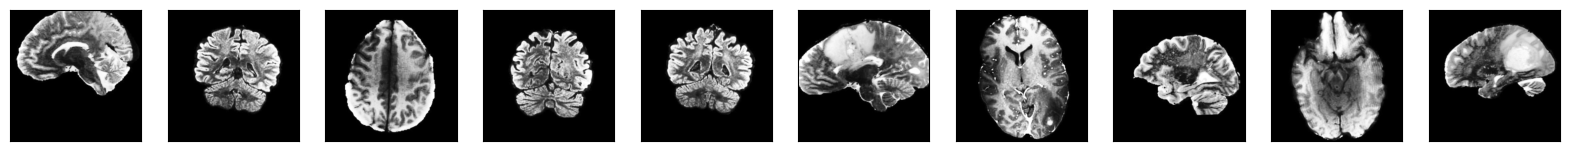

In [10]:
def plot(x_train, p , labels = False): 
    plt.figure(figsize = (20,2)) 
    for i in range(10): 
        ax=plt.subplot(1, 10, i+1) 
        plt.imshow(x_train[i].reshape(256,256)) 
        plt.xticks([]) 
        plt.yticks([]) 
        plt.gray()
        if labels: 
#             plt.xlabel(np.argmax(p[i])) 
            plt.show() 
    return 
plot(x_train, None) 

In [11]:
from keras.models import load_model
autoencoders = load_model('/kaggle/input/phaseone-p2-camp-weight/model_for_PhaseOne-Twodatasets-P2.h5')

2024-02-02 04:49:16.122585: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-02-02 04:49:16.122678: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-02-02 04:49:16.296002: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [12]:
autoencoders.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 256, 256, 1)]     0         
                                                                 
 conv2d (Conv2D)             (None, 256, 256, 64)      640       
                                                                 
 max_pooling2d (MaxPooling2  (None, 128, 128, 64)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 128, 128, 32)      18464     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 64, 64, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_transpose (Conv2DTr  (None, 128, 128, 32)      9248  

1/1 [==============================] - 3s 3s/step


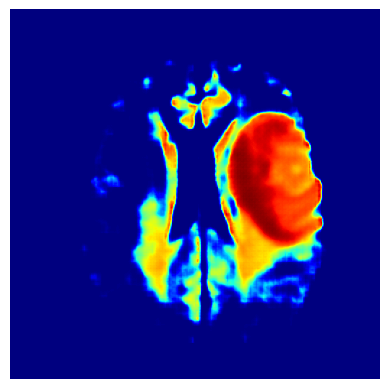

In [13]:
# ... [rest of the imports and code]
import cv2
def highlight_image_with_color(img_path):
    # ... [rest of the pre-processing]
    # Load and preprocess the MRI image
#     encoder1 = tf.keras.models.load_model('/kaggle/input/phaseone-p2-camp-weight/model_for_PhaseOne-Twodatasets-P2.h5')
    mri_img = Image.open(img_path)  # Use the img_path variable
#     mri_img = mri_img.resize((128, 128))  # Assuming the encoder expects 128x128 images
    mri_img_array = np.array(mri_img)
    
    # Normalize the image if required
    mri_img_array = mri_img_array / 255.0  # Assuming the image needs to be normalized to [0, 1]

    # Convert the grayscale MRI to RGB
    mri_rgb = np.stack((mri_img_array,) * 3, axis=-1)
    # Extract latent space features
    latent_features = autoencoders.predict(np.expand_dims(mri_img_array, axis=0))

    # Sum across the depth of the latent features to get a 2D heatmap
    heatmap = np.sum(latent_features, axis=-1)[0]

    # Resize this heatmap to match the size of the original image
    heatmap_resized = cv2.resize(heatmap, (mri_img_array.shape[1], mri_img_array.shape[0]))

    # Normalize the heatmap for visualization
    heatmap_resized = (heatmap_resized - np.min(heatmap_resized)) / (np.max(heatmap_resized) - np.min(heatmap_resized))

    plt.imshow(heatmap_resized, cmap='jet')  # Using a jet colormap to visualize the heatmap
    plt.axis('off')  # This will remove the axis and ticks
    plt.savefig("/kaggle/working/HeatmapofMRI-7.jpg", dpi=300, bbox_inches='tight', pad_inches=0)
    plt.show()

highlight_image_with_color('/kaggle/input/rsna-final-36-v14/Patients_New36/Patients_New36/00107/FLAIR/Image-19.JPEG')


In [14]:
from tensorflow.keras.models import Sequential, Model 
from tensorflow.keras.layers import Dense, Input, Flatten, LeakyReLU
# autoencoders.summary()

In [15]:
from keras import backend as K
def AdaptiveSparseRegularizer(activation_matrix):
    p = 0.2
    
    beta_min = 1.00  # minimum regularization strength
    beta_max = 5.00  # maximum regularization strength
    glob = 18464  # based on the code layer of the autoencoder
    
    p_hat = K.mean(activation_matrix)
    local = K.std(activation_matrix)
    KL_divergence = p * (K.log(p / p_hat)) + (1 - p) * (K.log(1 - p / (1 - p_hat)))
    sum_KL = K.sum(KL_divergence)
    
    # Adjust beta2 based on the KL divergence. If KL_divergence is high, beta2 will be closer to beta_max, and vice versa.
    beta2 = beta_min + (beta_max - beta_min) * KL_divergence
    
    result = beta2 * sum_KL  # Lambda
    return result

In [16]:
# import pynvml
# pynvml.nvmlInit()

# deviceCount = pynvml.nvmlDeviceGetCount()
# for i in range(deviceCount):
#     handle = pynvml.nvmlDeviceGetHandleByIndex(i)
#     print(f"Device {i} {pynvml.nvmlDeviceGetName(handle).decode()}")

In [17]:
from tensorflow.keras.layers import Conv2D, Flatten, MaxPooling2D, GlobalAveragePooling2D, BatchNormalization, Dense, Reshape, Dropout
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.regularizers import l1  # or any other regularizer
import keras

# ... assuming autoencoders is defined and compiled ...

# Make the autoencoder layers trainable for fine-tuning
for layer in autoencoders.layers:
    layer.trainable = True

# Start defining the new model
hidden = autoencoders.layers[-4].output
hidden = Reshape((64, 64, 32))(hidden)  # Adjust according to your actual data size and architecture
# hidden = Reshape((128,128, 32))(hidden)  # Adjust according to your actual data size and architecture

# hidden = BatchNormalization(name='BN_1')(hidden)
hidden = Conv2D(64, kernel_size=(2, 2), activation='relu', padding='same', name='hidden_layer1')(hidden)
hidden = MaxPooling2D((2, 2), padding="same", name='max_pool1')(hidden)
# hidden = BatchNormalization(name='BN_2')(hidden)
hidden = Conv2D(32, kernel_size=(2, 2), activation='relu', padding='same', name='hidden_layer2')(hidden)
hidden = GlobalAveragePooling2D()(hidden)
hidden = Flatten()(hidden)
hidden = Dense(64, activation='relu', activity_regularizer=AdaptiveSparseRegularizer, name='hidden_layer3')(hidden)  # Example with L1 regularization
hidden = Dropout(0.5)(hidden)  # Example with Dropout
outputs2 = Dense(1, activation='sigmoid')(hidden)

model = Model(inputs=autoencoders.input, outputs=outputs2)

# Compile the model
opt = keras.optimizers.Adam(learning_rate=0.01)
model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 256, 256, 1)]     0         
                                                                 
 conv2d (Conv2D)             (None, 256, 256, 64)      640       
                                                                 
 max_pooling2d (MaxPooling2  (None, 128, 128, 64)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 128, 128, 32)      18464     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 64, 64, 32)        0         
 g2D)                                                            
                                                                 
 reshape (Reshape)           (None, 64, 64, 32)        0     

In [18]:
# !pip install nvidia-smi

In [19]:
import pynvml
pynvml.nvmlInit()

deviceCount = pynvml.nvmlDeviceGetCount()
for i in range(deviceCount):
    handle = pynvml.nvmlDeviceGetHandleByIndex(i)
    print(f"Device {i} {pynvml.nvmlDeviceGetName(handle).decode()}")

Device 0 Tesla T4
Device 1 Tesla T4


Training on fold 0...


I0000 00:00:1706848093.842206      87 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


25/25 [==============================] - 2s 29ms/step
Training on fold 1...
25/25 [==============================] - 0s 14ms/step
Training on fold 2...
25/25 [==============================] - 1s 29ms/step
Training on fold 3...
25/25 [==============================] - 0s 14ms/step
Training on fold 4...
25/25 [==============================] - 0s 14ms/step


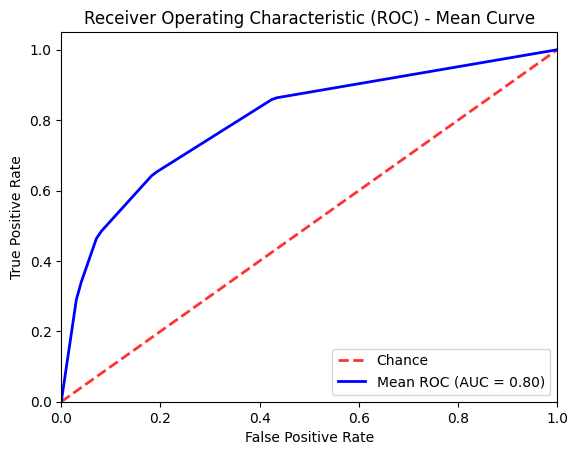

Mean Sensitivity: 0.8282576576665036
Mean Specificity: 0.770225247161578
Mean Recall: 0.8282576576665036
Mean Accuracy: 0.7970632658164541
Mean F1-Score: 0.788980315210941


In [19]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

def calculate_metrics(conf_matrix):
    tn, fp, fn, tp = conf_matrix.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    recall = tp / (tp + fn)
    return sensitivity, specificity, recall

k = 5  # Number of folds
kf = KFold(n_splits=k, shuffle=True, random_state=42)

sensitivity_scores = []
specificity_scores = []
recall_scores = []
accuracy_scores = []
f1_scores = []
roc_auc_scores = []
fold_no = 0

# Arrays to store false positive rates and true positive rates for each fold
mean_fpr = np.linspace(0, 1, 100)
mean_tpr_list = []

history_list = []  # To store training history for each fold

for train_index, val_index in kf.split(x_train):
    x_train_fold, x_val_fold = x_train[train_index], x_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]
    print(f"Training on fold {fold_no}...")
    model.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])
    
    # Training the model and storing the training history
    history = model.fit(x_train_fold, y_train_fold, epochs=10, batch_size=14, verbose=0)
    history_list.append(history)
    
    # Make predictions on the validation set
    y_pred = model.predict(x_val_fold).ravel()
    threshold = 0.5
    y_pred = (y_pred > threshold).astype(int)

    # Calculate the confusion matrix
    conf_matrix = confusion_matrix(y_val_fold, y_pred)

    # Calculate sensitivity, specificity, recall, accuracy, and F1-score for this fold
    sensitivity, specificity, recall = calculate_metrics(conf_matrix)
    accuracy = accuracy_score(y_val_fold, y_pred)
    f1 = f1_score(y_val_fold, y_pred)
    
    # Calculate ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_val_fold, y_pred)
    roc_auc = auc(fpr, tpr)
    roc_auc_scores.append(roc_auc)

    # Append the scores to the respective lists
    sensitivity_scores.append(sensitivity)
    specificity_scores.append(specificity)
    recall_scores.append(recall)
    accuracy_scores.append(accuracy)
    f1_scores.append(f1)

    # Append the ROC curve for this fold to the list
    mean_tpr_list.append(np.interp(mean_fpr, fpr, tpr))
    
    fold_no += 1

# Calculate the mean ROC curve
mean_tpr = np.mean(mean_tpr_list, axis=0)

# Create a DataFrame for the mean ROC curve
roc_curve_data = pd.DataFrame({'False Positive Rate': mean_fpr, 'True Positive Rate': mean_tpr})

# Save the DataFrame to a CSV file
roc_curve_data.to_csv('/kaggle/working/mean_roc_curve.csv', index=False)

# Plot the mean ROC curve
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='red', label='Chance', alpha=.8)
plt.plot(mean_fpr, mean_tpr, color='blue', lw=2, label=f'Mean ROC (AUC = {np.mean(roc_auc_scores):.2f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Mean Curve')
plt.legend(loc="lower right")
plt.show()
plt.close()

# Calculate the mean scores over all folds
mean_sensitivity = np.mean(sensitivity_scores)
mean_specificity = np.mean(specificity_scores)
mean_recall = np.mean(recall_scores)
mean_accuracy = np.mean(accuracy_scores)
mean_f1 = np.mean(f1_scores)

print("Mean Sensitivity:", mean_sensitivity)
print("Mean Specificity:", mean_specificity)
print("Mean Recall:", mean_recall)
print("Mean Accuracy:", mean_accuracy)
print("Mean F1-Score:", mean_f1)

In [20]:
import tensorflow as tf 
checkpointer = tf.keras.callbacks.ModelCheckpoint('/kaggle/working/model_for_PhaseOne-Twodatasets-P2.h5', verbose=1, save_best_only=True)
csv_logger = tf.keras.callbacks.CSVLogger('/kaggle/working.csv', separator=",", append=False)
callbacks = [tf.keras.callbacks.EarlyStopping(patience=14, monitor='val_loss'),tf.keras.callbacks.TensorBoard(log_dir='logs')]
history = model.fit(x_train, y_train, batch_size=8, epochs=50,callbacks=[checkpointer,csv_logger], shuffle = True, validation_data=(x_test, y_test))

Epoch 1/50
484/484 [==============================] - ETA: 0s - loss: 0.1948 - accuracy: 0.9243
Epoch 1: val_loss improved from inf to 0.20474, saving model to /kaggle/working/model_for_PhaseOne-Twodatasets-P2.h5
484/484 [==============================] - 11s 20ms/step - loss: 0.1948 - accuracy: 0.9243 - val_loss: 0.2047 - val_accuracy: 0.9256
Epoch 2/50
  8/484 [..............................] - ETA: 7s - loss: 0.0607 - accuracy: 0.9844

/opt/conda/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
/opt/conda/lib/python3.10/site-packages/keras/src/regularizers.py:426: UserWarning: The `keras.regularizers.serialize()` API should only be used for objects of type `keras.regularizers.Regularizer`. Found an instance of type <class 'function'>, which may lead to improper serialization.
  warnings.warn(


484/484 [==============================] - ETA: 0s - loss: 0.1831 - accuracy: 0.9290
Epoch 2: val_loss did not improve from 0.20474
484/484 [==============================] - 9s 18ms/step - loss: 0.1831 - accuracy: 0.9290 - val_loss: 0.2088 - val_accuracy: 0.9184
Epoch 3/50
483/484 [============================>.] - ETA: 0s - loss: 0.1489 - accuracy: 0.9451
Epoch 3: val_loss did not improve from 0.20474
484/484 [==============================] - 9s 18ms/step - loss: 0.1488 - accuracy: 0.9452 - val_loss: 0.2326 - val_accuracy: 0.9029
Epoch 4/50
483/484 [============================>.] - ETA: 0s - loss: 0.1877 - accuracy: 0.9265
Epoch 4: val_loss improved from 0.20474 to 0.17890, saving model to /kaggle/working/model_for_PhaseOne-Twodatasets-P2.h5
484/484 [==============================] - 9s 18ms/step - loss: 0.1877 - accuracy: 0.9264 - val_loss: 0.1789 - val_accuracy: 0.9287
Epoch 5/50
483/484 [============================>.] - ETA: 0s - loss: 0.1356 - accuracy: 0.9477
Epoch 5: val_los

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array, load_img

def occlusion_analysis(model, image_path, window_size, target_class):
    # Load and preprocess the image
    original_image = load_img(image_path, target_size=(256, 256), color_mode='grayscale')  # Set color_mode to 'grayscale'
    original_image = img_to_array(original_image) / 255.0

    # Reshape the image to have a single channel if necessary
    if original_image.shape[-1] != 1:
        original_image = original_image.reshape((original_image.shape[0], original_image.shape[1], 1))

    heatmap = np.zeros((256, 256))

    # Iterate over the image
    for y in range(0, 256, window_size):
        for x in range(0, 256, window_size):
            # Occlude the image
            occluded_image = np.array(original_image)
            occluded_image[y:y + window_size, x:x + window_size, :] = 0

            # Make a prediction
            preds = model.predict(np.expand_dims(occluded_image, axis=0))
            
            # Update heatmap (example for a binary classifier)
            heatmap[y:y + window_size, x:x + window_size] = preds[0][target_class]

    return heatmap

custom_objects = {"AdaptiveSparseRegularizer": AdaptiveSparseRegularizer}

# model = load_model('/kaggle/input/phaseone-p2-camp-weight/model_for_PhaseOne-Twodatasets-P2.h5')

model = load_model('/kaggle/working/model_for_PhaseOne-Twodatasets-P2.h5', custom_objects=custom_objects)

heatmap = occlusion_analysis(model, '/kaggle/input/rsna-final-36-v14/Patients_New36/Patients_New36/00107/FLAIR/Image-19.JPEG', window_size=10, target_class=0)


OSError: No file or directory found at /kaggle/working/model_for_PhaseOne-Twodatasets-P2.h5